Project Summary

This project investigates the relationship between plant-based food sales and
YouTube narratives across European countries from 2018 to 2020. The analysis
combines two types of data: sales data for plant-based food products and
YouTube video metadata collected through the YouTube Data API.

The sales analysis examines descriptive patterns across countries, years, and
product groups. Average sales value in EUR and sales volume in kg/l are compared
to identify market differences between countries, changes over time, and
variation across product categories.

The YouTube analysis focuses on narrative themes in video titles and
descriptions. Five narrative categories are measured using keyword-based text
analysis: health, sustainability, environment, hedonism, and animal welfare.
These narrative variables are summarized by country and year to explore how
plant-based food discussions differ across markets and change over time.

Finally, the sales data and YouTube narrative data are merged at the
country-year level. Correlation and regression analyses are used to explore
whether YouTube attention and narrative intensity are associated with sales
value and sales volume. The results are interpreted as exploratory rather than
causal, since sales performance may also be influenced by prices, product
availability, market maturity, and retail conditions.

- Main RQ: How are plant-based food sales patterns related to YouTube narratives across European countries from 2018 to 2020?
- Sub-RQ1: How do plant-based food sales differ across countries, years, and product groups?
- Sub-RQ2: What narratives are most commonly used in YouTube videos about plant-based food across countries and over time?
- Sub-RQ3: To what extent are YouTube narrative variables associated with plant-based food sales value and sales volume?

In [123]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt

print(f"current working directory:{os.getcwd()}")
print("Files in current directory:")
print(os.listdir("."))

current working directory:e:\东京大学\Video-Analysis--DataScience-Group\notebooks
Files in current directory:
['0603 Group I.py', '0610 Group I.ipynb']


In [124]:
df = pd.read_csv("../data/Clean/plant_based_food_sales_data.csv")
def basics(df):
    print(df.info())
    print(df.head())
basics(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557 entries, 0 to 3556
Data columns (total 40 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product Group              3545 non-null   object 
 1   Product Group Detail       3545 non-null   object 
 2   Aggregation Level          3545 non-null   object 
 3   Cleaning Basis             3545 non-null   object 
 4   Original Product Group     3545 non-null   object 
 5   Source File                3545 non-null   object 
 6   Source Sheet               3545 non-null   object 
 7   Country                    3545 non-null   object 
 8   Market                     3545 non-null   object 
 9   Retail Channel             3545 non-null   object 
 10  Product Category           3539 non-null   object 
 11  Product Segment            3468 non-null   object 
 12  Product Subsegment         0 non-null      float64
 13  Product Type               2649 non-null   objec

In [125]:
df= df[['Country', 'Year', 'Value EUR', 'Volume kg/l', 'Product Group']]
df = df.dropna()
df = df[(df['Value EUR'] != 0) & (df['Volume kg/l'] != 0)]
df = (df.groupby(['Country', 'Year', 'Product Group'], as_index=False)[['Value EUR', 'Volume kg/l']].sum())

In [126]:
def details(df):
    print('Head')
    print(df.head(2))
    print('Tail')
    print(df.tail(2))
    print("\nUnique countries in the dataset:")
    print(df.Country.unique())
    print("\nUnique years in the dataset:")
    print(df.Year.unique())
    print("\nUnique product groups in the dataset:")
    print(df['Product Group'].unique())
details(df)

Head
   Country    Year                                     Product Group  \
0  Austria  2018.0  Plant-based meat/fish alternatives & ready meals   
1  Austria  2018.0                         Plant-based milk & drinks   

    Value EUR  Volume kg/l  
0  47756571.0    4539225.6  
1  60439596.8   30683478.8  
Tail
           Country    Year              Product Group     Value EUR  \
98  United Kingdom  2020.0  Plant-based milk & drinks  4.523603e+08   
99  United Kingdom  2020.0         Plant-based yogurt  3.031181e+07   

    Volume kg/l  
98  291010516.4  
99    6468243.4  

Unique countries in the dataset:
['Austria' 'Belgium' 'Denmark' 'France' 'Italy' 'Netherlands' 'Romania'
 'Spain' 'United Kingdom']

Unique years in the dataset:
[2018. 2019. 2020.]

Unique product groups in the dataset:
['Plant-based meat/fish alternatives & ready meals'
 'Plant-based milk & drinks' 'Plant-based yogurt' 'Plant-based cheese'
 'Plant-based ice cream' 'Other plant-based foods / snacks & spreads']


array([[<Axes: title={'center': 'Value EUR'}>,
        <Axes: title={'center': 'Volume kg/l'}>]], dtype=object)

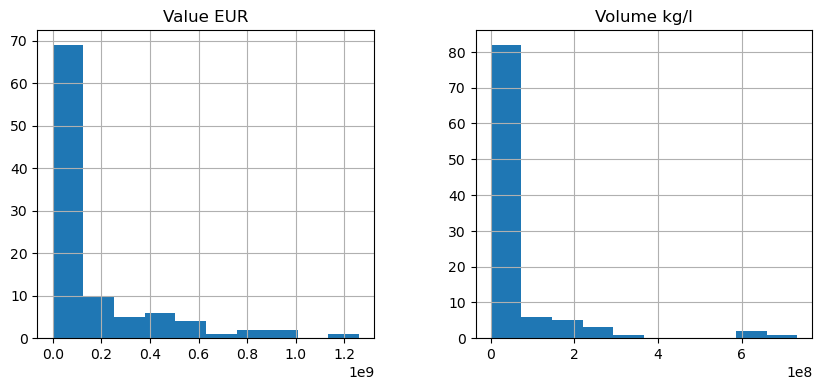

In [127]:
df[['Value EUR', 'Volume kg/l']].hist(figsize=(10, 4))

The histograms show that both sales value and sales volume are strongly right-skewed, with most observations concentrated at lower levels and only a small number of observations showing very large values. This indicates substantial variation across countries, years, and product categories. Since the dataset contains both value and volume information, the subsequent analysis examines whether higher sales volumes are associated with higher sales values, which would suggest a broadly positive value–volume relationship. Applying log transformation helps reduce the influence of extreme observations and makes the variables more suitable for regression analysis when testing this relationship.

array([[<Axes: title={'center': 'log_value'}>,
        <Axes: title={'center': 'log_volume'}>]], dtype=object)

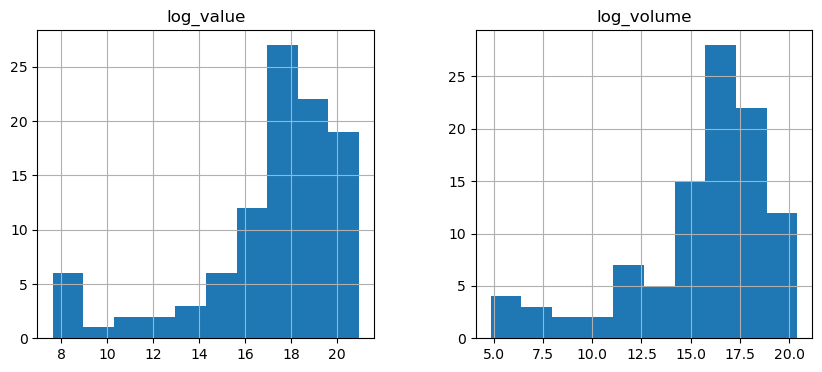

In [128]:
import numpy as np
df['log_value'] = np.log(df['Value EUR'])
df['log_volume'] = np.log(df['Volume kg/l'])
df[['log_value', 'log_volume']].hist(figsize=(10, 4))

After log transformation, the distributions of log_value and log_volume become less right-skewed compared with the original variables. The values are more spread out and less dominated by extreme observations, making them more suitable for correlation and OLS regression analysis.

In [129]:
import statsmodels.api as sm
X = sm.add_constant(df[['log_volume']])
y = df['log_value']
model_log = sm.OLS(y, X).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:              log_value   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     2176.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.01e-68
Time:                        15:07:56   Log-Likelihood:                -98.560
No. Observations:                 100   AIC:                             201.1
Df Residuals:                      98   BIC:                             206.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8911      0.290     13.424      0.0

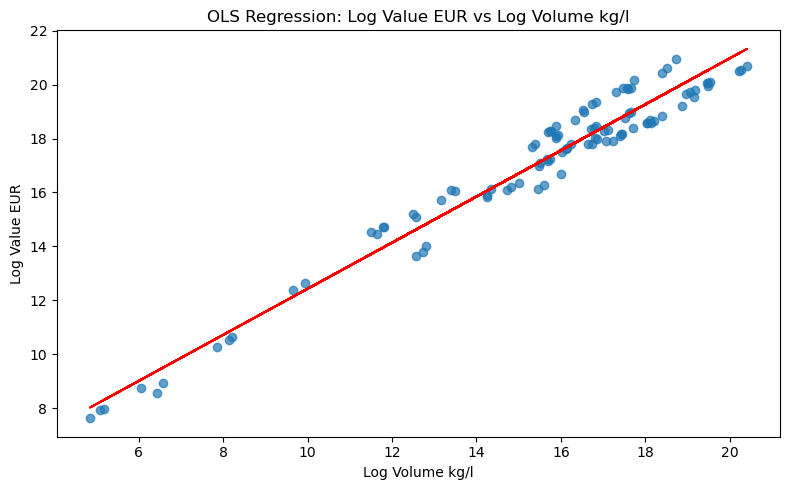

In [130]:
plt.figure(figsize=(8, 5))
plt.scatter(df['log_volume'], df['log_value'], alpha=0.7)
plt.plot(df['log_volume'], model_log.predict(X),color='red')
plt.title('OLS Regression: Log Value EUR vs Log Volume kg/l')
plt.xlabel('Log Volume kg/l')
plt.ylabel('Log Value EUR')
plt.tight_layout()
plt.show()

The log-log OLS regression shows a strong positive relationship between Volume kg/l and Value EUR. The model has a high R-squared value of 0.957, indicating that log volume explains most of the variation in log sales value. The coefficient of log_volume is positive and statistically significant, suggesting that higher sales volume is strongly associated with higher sales value. Therefore, since value and volume are highly correlated, the following analysis focuses on Value EUR as the main indicator and does not discuss Volume kg/l separately.

In [131]:
df_wide_value = df.pivot(
    index=['Country', 'Year'],
    columns='Product Group',
    values='Value EUR')
df_wide_value = df_wide_value.reset_index()
df_wide_value.columns.name = None
df_wide_value.head()

,Country,Year,Other plant-based foods / snacks & spreads,Plant-based cheese,Plant-based ice cream,Plant-based meat/fish alternatives & ready meals,Plant-based milk & drinks,Plant-based yogurt
0,Austria,2018.0,NaN,NaN,NaN,47756571.0,60439596.8,28291439.0
1,Austria,2019.0,NaN,NaN,NaN,53453292.6,70771713.8,30617819.8
2,Austria,2020.0,NaN,NaN,NaN,86449040.1,95499407.6,40249951.8
3,Belgium,2018.0,NaN,NaN,NaN,82826628.6,116339917.4,43862862.0
4,Belgium,2019.0,NaN,NaN,NaN,87256217.5,116808606.3,46100561.0


In [132]:
df_wide_value['Total Value EUR'] = (df_wide_value.drop(columns=['Country', 'Year']).sum(axis=1))
df_wide_value.head()

,Country,Year,Other plant-based foods / snacks & spreads,Plant-based cheese,Plant-based ice cream,Plant-based meat/fish alternatives & ready meals,Plant-based milk & drinks,Plant-based yogurt,Total Value EUR
0,Austria,2018.0,NaN,NaN,NaN,47756571.0,60439596.8,28291439.0,136487606.8
1,Austria,2019.0,NaN,NaN,NaN,53453292.6,70771713.8,30617819.8,154842826.2
2,Austria,2020.0,NaN,NaN,NaN,86449040.1,95499407.6,40249951.8,222198399.5
3,Belgium,2018.0,NaN,NaN,NaN,82826628.6,116339917.4,43862862.0,243029408.0
4,Belgium,2019.0,NaN,NaN,NaN,87256217.5,116808606.3,46100561.0,250165384.8


In [133]:
country_descriptive = df_wide_value.groupby(['Country'])[['Total Value EUR']].describe()
country_descriptive

Total Value EUR                                            \
                         count          mean           std           min   
Country                                                                    
Austria                    3.0  1.711763e+08  4.512949e+07  1.364876e+08   
Belgium                    3.0  2.599085e+08  2.332998e+07  2.430294e+08   
Denmark                    3.0  8.203163e+07  1.129062e+07  6.907380e+07   
France                     3.0  7.610923e+08  8.409217e+07  6.713733e+08   
Italy                      3.0  1.116265e+09  2.726988e+07  1.089518e+09   
Netherlands                3.0  6.583211e+08  1.444540e+08  5.350270e+08   
Romania                    3.0  2.283707e+07  5.585797e+06  1.858581e+07   
Spain                      3.0  1.029092e+09  1.821256e+08  8.491867e+08   
United Kingdom             3.0  1.334718e+09  3.848071e+08  1.000049e+09   

                                                                        
                         25%           50%           75%           max  
Country                                                                 
Austria         1.456652e+08  1.548428e+08  1.885206e+08  2.221984e+08  
Belgium         2.465974e+08  2.501654e+08  2.683481e+08  2.865308e+08  
Denmark         7.816988e+07  8.726596e+07  8.851055e+07  8.975514e+07  
France          7.225817e+08  7.737901e+08  8.059518e+08  8.381134e+08  
Italy           1.102383e+09  1.115248e+09  1.129639e+09  1.144029e+09  
Netherlands     5.788511e+08  6.226752e+08  7.199681e+08  8.172609e+08  
Romania         1.967389e+07  2.076197e+07  2.496271e+07  2.916344e+07  
Spain           9.369578e+08  1.024729e+09  1.119044e+09  1.213359e+09  
United Kingdom  1.124487e+09  1.248924e+09  1.502053e+09  1.755181e+09

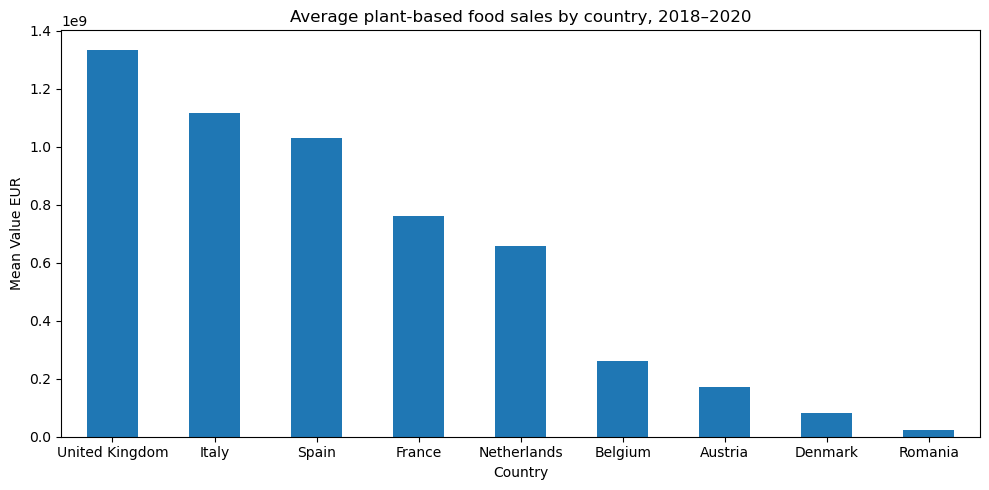

In [134]:
mean_value = country_descriptive[('Total Value EUR', 'mean')].sort_values(ascending=False)
mean_value.plot(kind='bar', figsize=(10, 5))
plt.title('Average plant-based food sales by country, 2018–2020')
plt.xlabel('Country')
plt.ylabel('Mean Value EUR')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The figure shows a clear concentration of plant-based food sales in a small number of markets from 2018 to 2020. The United Kingdom, Italy, and Spain accounted for the highest average sales values, suggesting that these countries had relatively larger and more developed plant-based food markets during this period. By contrast, countries such as Denmark and Romania showed much smaller sales values, indicating that market size differed substantially across Europe. This pattern suggests that plant-based food market development was uneven, with growth opportunities likely depending on country-specific market scale and consumer demand.

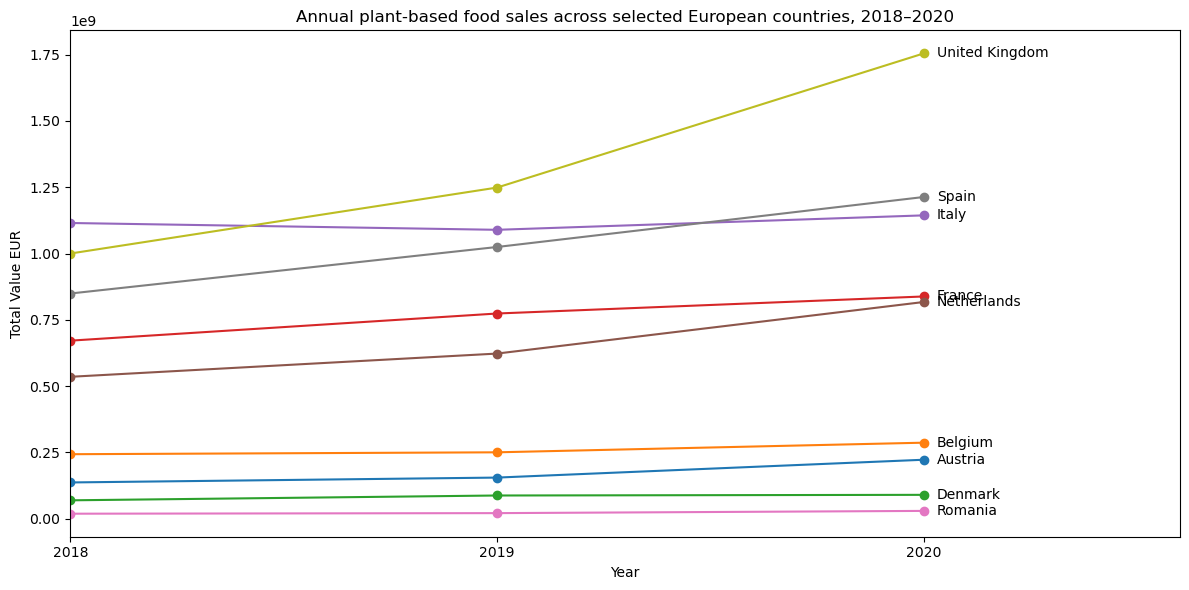

In [135]:
df_wide_value_wide = df_wide_value.pivot(
    index='Year',
    columns='Country',
    values='Total Value EUR')

ax = df_wide_value_wide.plot(
    figsize=(12, 6),
    marker='o',
    legend=False)

for country in df_wide_value_wide.columns:
    last_year = df_wide_value_wide.index[-1]
    last_value = df_wide_value_wide[country].iloc[-1]
    ax.text(last_year + 0.03, last_value, country, va='center')

plt.title('Annual plant-based food sales across selected European countries, 2018–2020')
plt.xlabel('Year')
plt.ylabel('Total Value EUR')
plt.xticks(df_wide_value_wide.index)
plt.xlim(df_wide_value_wide.index.min(), df_wide_value_wide.index.max() + 0.6)
plt.tight_layout()
plt.show()

Plant-based food sales increased in most selected European countries from 2018 to 2020, but the pace and scale of growth differed clearly across markets. The United Kingdom showed the strongest upward trend and became the leading market by 2020, while Spain and Italy remained consistently large markets. In contrast, countries such as Denmark and Romania stayed at much lower sales levels, suggesting that market expansion was uneven and mainly driven by a few major countries.

In [136]:
product_cols = df_wide_value.columns.drop(['Country', 'Year', 'Total Value EUR'])
df_share = df_wide_value.copy()
df_share[product_cols] = (df_wide_value[product_cols].div(df_wide_value['Total Value EUR'], axis=0) * 100)
df_share.head()

,Country,Year,Other plant-based foods / snacks & spreads,Plant-based cheese,Plant-based ice cream,Plant-based meat/fish alternatives & ready meals,Plant-based milk & drinks,Plant-based yogurt,Total Value EUR
0,Austria,2018.0,NaN,NaN,NaN,34.989676,44.282113,20.728211,136487606.8
1,Austria,2019.0,NaN,NaN,NaN,34.521000,45.705517,19.773483,154842826.2
2,Austria,2020.0,NaN,NaN,NaN,38.906239,42.979341,18.114420,222198399.5
3,Belgium,2018.0,NaN,NaN,NaN,34.080908,47.870716,18.048376,243029408.0
4,Belgium,2019.0,NaN,NaN,NaN,34.879413,46.692554,18.428034,250165384.8


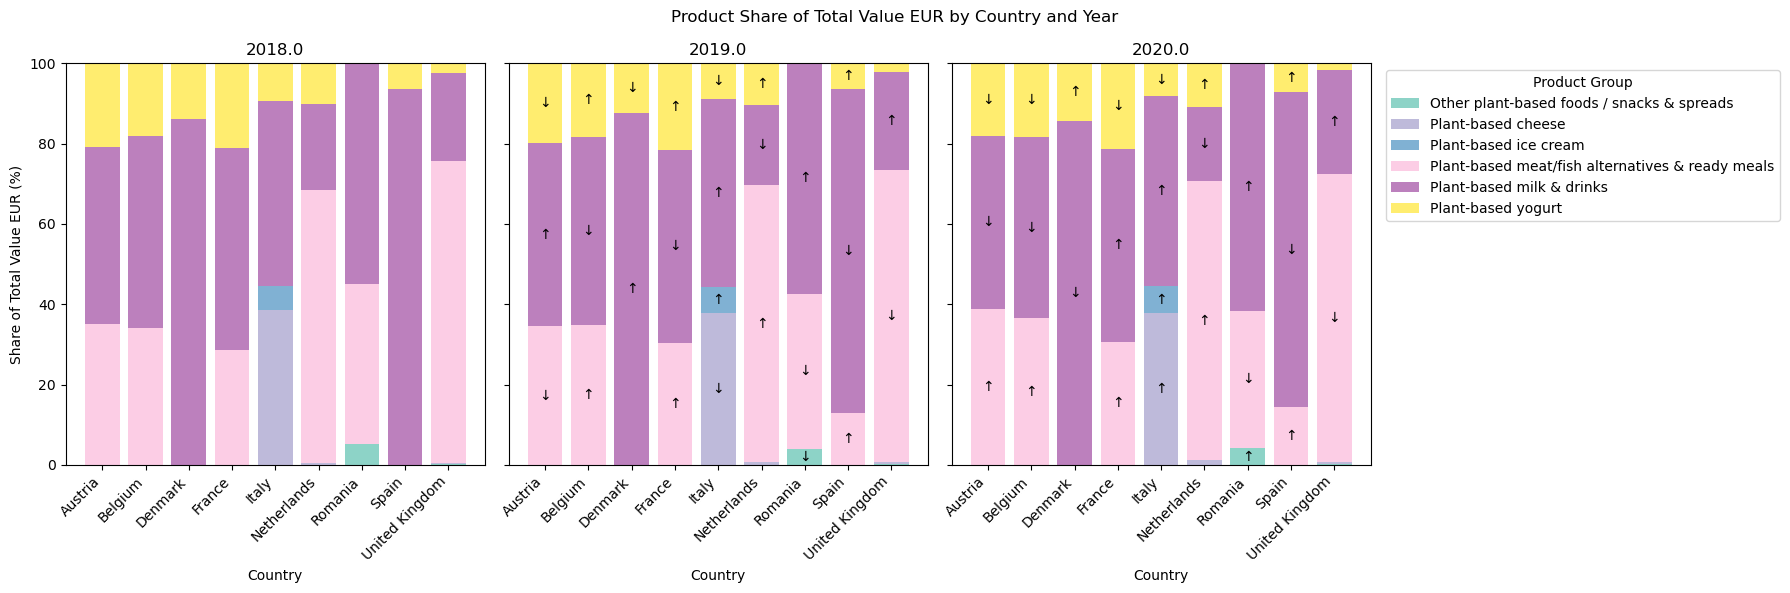

In [137]:
import numpy as np
years = sorted(df_share['Year'].unique())
countries = sorted(df_share['Country'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(18, 6), sharey=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(product_cols)))
for i, year in enumerate(years):
    ax = axes[i]
    data = (df_share[df_share['Year'] == year].set_index('Country').reindex(countries)[product_cols].fillna(0))
    bottom = np.zeros(len(countries))
    for j, product in enumerate(product_cols):
        values = data[product].values
        ax.bar(countries,values,bottom=bottom,label=product,color=colors[j])
        if i > 0:
            prev_year = years[i - 1]
            prev_data = (df_share[df_share['Year'] == prev_year].set_index('Country').reindex(countries)[product_cols].fillna(0))
            change = data[product].values - prev_data[product].values
            for x, value, base, diff in zip(range(len(countries)), values, bottom, change):
                if value > 3:
                    if diff > 0:
                        ax.text(x, base + value / 2, '↑', ha='center', va='center')
                    elif diff < 0:
                        ax.text(x, base + value / 2, '↓', ha='center', va='center')
        bottom += values
    ax.set_title(str(year))
    ax.set_xlabel('Country')
    ax.set_xticks(range(len(countries)))
    ax.set_xticklabels(countries, rotation=45, ha='right')
    ax.set_ylim(0, 100)
axes[0].set_ylabel('Share of Total Value EUR (%)')

plt.suptitle('Product Share of Total Value EUR by Country and Year')
plt.legend(title='Product Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

The figure shows that the contribution of different product categories to total plant-based food sales varied substantially across countries and years. Plant-based milk and drinks accounted for a large share in many countries, especially in Denmark, Spain, Austria, Belgium, and France, indicating that this category was a key driver of total sales. In contrast, plant-based meat/fish alternatives and ready meals represented a particularly large share in the United Kingdom and the Netherlands, suggesting that these markets were more strongly shaped by meat-alternative products. The arrows show that category shares changed over time, but the overall market structure remained relatively stable in several countries. This suggests that plant-based food markets were not homogeneous across Europe; instead, each country appeared to have a different product-category profile, which may reflect differences in consumer preferences and market development pathways.

API

> **Note:** The following code was used to extract video information through the YouTube API. Since it requires a personal API key and repeated execution may trigger API quota limits, it is included as a Markdown section rather than an executable code cell. The CSV files generated from this process are then combined in the next step into a complete CSV file and stored in the `data/Raw` folder.


import requests
import pandas as pd
import time
from pathlib import Path
from datetime import datetime

API_KEY = "PASTE YOUR OWN API_KEY"

PAGES_PER_QUERY = 1
REQUEST_SLEEP_SECONDS = 2

PUBLISHED_AFTER = "2018-01-01T00:00:00Z"
PUBLISHED_BEFORE = "2021-01-01T00:00:00Z"

OUTPUT_DIR =Path("../data/Raw")

COUNTRIES = [
    {"country": "Austria", "region_code": "AT", "language": "de", "local_name": "Austria Osterreich"},
    {"country": "Belgium", "region_code": "BE", "language": "nl", "local_name": "Belgium Belgie Belgique"},
    {"country": "Denmark", "region_code": "DK", "language": "da", "local_name": "Denmark Danmark"},
    {"country": "France", "region_code": "FR", "language": "fr", "local_name": "France"},
    {"country": "Italy", "region_code": "IT", "language": "it", "local_name": "Italy Italia"},
    {"country": "Netherlands", "region_code": "NL", "language": "nl", "local_name": "Netherlands Nederland"},
    {"country": "Romania", "region_code": "RO", "language": "ro", "local_name": "Romania"},
    {"country": "Spain", "region_code": "ES", "language": "es", "local_name": "Spain Espana"},
    {"country": "United Kingdom", "region_code": "GB", "language": "en", "local_name": "United Kingdom UK Britain"},
]

# Change this later if you want another country
SELECTED_COUNTRY_NAME = "United Kingdom"

QUERY_TEMPLATES = [
    "plant based food {country} consumer behaviour",
    "plant based meat {country} consumers",
    "vegan food {country} consumer trends",
    "plant based diet {country} supermarket",
    "meat alternatives {country} shoppers",
    "vegan products {country} consumers",
    "plant based food {local_name} sustainability",
    "vegan {local_name} supermarket",
]


def get_country_config(country_name):
    for country in COUNTRIES:
        if country["country"] == country_name:
            return country
    raise ValueError(f"Country not found: {country_name}")


def youtube_get(endpoint, params, max_retries=5):
    url = f"https://www.googleapis.com/youtube/v3/{endpoint}"
    params = dict(params)
    params["key"] = API_KEY

    for attempt in range(max_retries):
        response = requests.get(url, params=params, timeout=30)

        if response.status_code == 429:
            wait_time = 30 * (attempt + 1)
            print(f"429 Too Many Requests. Waiting {wait_time} seconds...")
            time.sleep(wait_time)
            continue

        if response.status_code == 403:
            print("403 error. You may have reached your YouTube API quota limit.")
            print(response.text)
            response.raise_for_status()

        response.raise_for_status()
        time.sleep(REQUEST_SLEEP_SECONDS)
        return response.json()

    raise Exception("Too many requests. Please wait and run again later.")


def search_videos(country_config):
    video_rows = []
    seen = set()

    queries = [
        template.format(
            country=country_config["country"],
            local_name=country_config["local_name"]
        )
        for template in QUERY_TEMPLATES
    ]

    for query in queries:
        print("Query:", query)

        page_token = None

        for _ in range(PAGES_PER_QUERY):
            params = {
                "part": "snippet",
                "type": "video",
                "q": query,
                "maxResults": 50,
                "regionCode": country_config["region_code"],
                "relevanceLanguage": country_config["language"],
                "publishedAfter": PUBLISHED_AFTER,
                "publishedBefore": PUBLISHED_BEFORE,
                "safeSearch": "none",
                "order": "relevance",
            }

            if page_token:
                params["pageToken"] = page_token

            data = youtube_get("search", params)

            for item in data.get("items", []):
                video_id = item.get("id", {}).get("videoId")

                if video_id and video_id not in seen:
                    seen.add(video_id)
                    video_rows.append({
                        "country": country_config["country"],
                        "search_region_code": country_config["region_code"],
                        "search_language": country_config["language"],
                        "video_id": video_id,
                    })

            page_token = data.get("nextPageToken")

            if not page_token:
                break

    return video_rows


def fetch_video_details(video_ids):
    all_items = []

    for start in range(0, len(video_ids), 50):
        chunk = video_ids[start:start + 50]

        if len(chunk) == 0:
            continue

        params = {
            "part": "snippet,statistics,contentDetails",
            "id": ",".join(chunk),
            "maxResults": 50,
        }

        data = youtube_get("videos", params)
        all_items.extend(data.get("items", []))

    return all_items


def fetch_channel_details(channel_ids):
    channels = {}
    unique_channel_ids = list(set(channel_ids))

    for start in range(0, len(unique_channel_ids), 50):
        chunk = unique_channel_ids[start:start + 50]

        if len(chunk) == 0:
            continue

        params = {
            "part": "snippet,statistics,brandingSettings",
            "id": ",".join(chunk),
            "maxResults": 50,
        }

        data = youtube_get("channels", params)

        for item in data.get("items", []):
            channels[item["id"]] = item

    return channels


def clean_text(text):
    if text is None:
        return ""
    return " ".join(str(text).replace("\n", " ").replace("\r", " ").split())


def build_final_rows(search_rows, video_details, channel_details):
    details_by_id = {
        item["id"]: item
        for item in video_details
    }

    final_rows = []

    for row in search_rows:
        video_id = row["video_id"]
        item = details_by_id.get(video_id)

        if item is None:
            continue

        snippet = item.get("snippet", {})
        statistics = item.get("statistics", {})

        channel_id = snippet.get("channelId", "")
        channel = channel_details.get(channel_id, {})

        channel_country = (
            channel
            .get("brandingSettings", {})
            .get("channel", {})
            .get("country", "")
        )

        published_at = snippet.get("publishedAt", "")

        final_rows.append({
            "country": row["country"],
            "search_region_code": row["search_region_code"],
            "search_language": row["search_language"],
            "channel_country": channel_country,
            "default_language": snippet.get("defaultLanguage", ""),
            "default_audio_language": snippet.get("defaultAudioLanguage", ""),
            "video_id": video_id,
            "url": f"https://www.youtube.com/watch?v={video_id}",
            "title": clean_text(snippet.get("title", "")),
            "upload_date": published_at[:10],
            "published_at": published_at,
            "channel": snippet.get("channelTitle", ""),
            "channel_id": channel_id,
            "view_count": statistics.get("viewCount", ""),
            "like_count": statistics.get("likeCount", ""),
            "comment_count": statistics.get("commentCount", ""),
            "description": clean_text(snippet.get("description", "")),
        })

    return final_rows


country_config = get_country_config(SELECTED_COUNTRY_NAME)

print("==============================")
print(f"Searching {country_config['country']}")
print("==============================")

search_rows = search_videos(country_config)
search_df = pd.DataFrame(search_rows)

print("\nTotal rows:", len(search_df))

if len(search_df) > 0:
    print("Unique videos:", search_df["video_id"].nunique())

    unique_video_ids = search_df["video_id"].drop_duplicates().tolist()

    print("\nFetching video details...")
    video_details = fetch_video_details(unique_video_ids)

    channel_ids = [
        item.get("snippet", {}).get("channelId")
        for item in video_details
        if item.get("snippet", {}).get("channelId")
    ]

    print("Fetching channel details...")
    channel_details = fetch_channel_details(channel_ids)

    final_rows = build_final_rows(
        search_rows,
        video_details,
        channel_details
    )

    df_youtube = pd.DataFrame(final_rows)

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    country_file_name = SELECTED_COUNTRY_NAME.lower().replace(" ", "_")

    csv_path = OUTPUT_DIR / f"youtube_plant_based_{country_file_name}_{stamp}.csv"
    json_path = OUTPUT_DIR / f"youtube_plant_based_{country_file_name}_{stamp}.json"

    df_youtube.to_csv(csv_path, index=False, encoding="utf-8-sig")
    df_youtube.to_json(json_path, orient="records", force_ascii=False, indent=2)

    print("\nDone.")
    print("Rows saved:", len(df_youtube))
    print("CSV saved to:", csv_path)
    print("JSON saved to:", json_path)

    display(df_youtube.head())

else:
    print("No videos found. Try changing queries or checking your API key.")

In [138]:
from pathlib import Path

# Folder where your country-level YouTube CSV files are saved
folder = Path("../data/Raw")

# Find all country-level CSV files
csv_files = list(folder.glob("youtube_plant_based_*.csv"))

# Exclude already-combined files if they exist
csv_files = [
    file for file in csv_files
    if "all_countries" not in file.name
]

print("Number of CSV files found:", len(csv_files))

for file in csv_files:
    print(file.name)

if len(csv_files) == 0:
    raise ValueError("No CSV files found. Please check your folder path.")

df_list = []

for file in csv_files:
    temp_df = pd.read_csv(file)

    # Add source file name for tracking
    temp_df["source_file"] = file.name

    df_list.append(temp_df)

# Combine all CSV files
df_all_youtube = pd.concat(df_list, ignore_index=True)

# Remove duplicated rows if the same video appears more than once for the same country
if {"country", "video_id"}.issubset(df_all_youtube.columns):
    df_all_youtube = df_all_youtube.drop_duplicates(
        subset=["country", "video_id"]
    )
else:
    print("Warning: country or video_id column not found. Skipping duplicate removal by country and video_id.")

# Save combined CSV
output_path = folder / "youtube_plant_based_all_countries.csv"

df_all_youtube.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nDone.")
print("Total rows:", len(df_all_youtube))
print("Saved to:", output_path)

display(df_all_youtube.head())

Number of CSV files found: 9
youtube_plant_based_austria_20260602_214414.csv
youtube_plant_based_belgium_20260602_214556.csv
youtube_plant_based_denmark_20260602_214710.csv
youtube_plant_based_france_20260602_214839.csv
youtube_plant_based_italy_20260602_215007.csv
youtube_plant_based_netherlands_20260602_215107.csv
youtube_plant_based_romania_20260602_215157.csv
youtube_plant_based_spain_20260602_215249.csv
youtube_plant_based_united_kingdom_20260602_214155.csv

Done.
Total rows: 2843
Saved to: ..\data\Raw\youtube_plant_based_all_countries.csv


,country,search_region_code,search_language,channel_country,default_language,default_audio_language,video_id,url,title,upload_date,published_at,channel,channel_id,view_count,like_count,comment_count,description,source_file
0,Austria,AT,de,US,en,en,MZsoQqMnPZI,https://www.youtube.com/watch?v=MZsoQqMnPZI,Janitorial Restroom Cleaning Step-By-Step Trai...,2018-09-13,2018-09-13T19:58:15Z,Relay Resources,UCA9jhkyeyeU3NS57ATgmAXw,2183087,25217.0,121.0,A building interior sets the stage for how peo...,youtube_plant_based_austria_20260602_214414.csv
1,Austria,AT,de,US,en,en,4a4gshhnb7Q,https://www.youtube.com/watch?v=4a4gshhnb7Q,Why Mcdonalds Doesnt Have a Vegan Burger in th...,2019-06-21,2019-06-21T20:48:57Z,Ripe,UC2OuoOnXZ-EosStugaJoWsg,431,19.0,4.0,"While fast food chains Burger King, White Cast...",youtube_plant_based_austria_20260602_214414.csv
2,Austria,AT,de,US,en,NaN,GGc-Z1AyIFY,https://www.youtube.com/watch?v=GGc-Z1AyIFY,H.O.P.E - The Documentary - What You Eat Matte...,2020-04-02,2020-04-02T15:14:16Z,Indie Film Trailers,UCyR9ic1YgBCOHK5HSYdN1IA,115,2.0,0.0,Half of the population in Western society suff...,youtube_plant_based_austria_20260602_214414.csv
3,Austria,AT,de,NaN,en,NaN,I7oLRSEt7Ag,https://www.youtube.com/watch?v=I7oLRSEt7Ag,H O P E What You Eat Matters - Trailer,2020-10-07,2020-10-07T12:27:42Z,Films For Change,UC3oDRtIlvdaVfHoDEtbl6MQ,15,0.0,0.0,Watch the film: https://filmsforchange.stream/...,youtube_plant_based_austria_20260602_214414.csv
4,Austria,AT,de,DE,de,zxx,msbyMI-aZ0o,https://www.youtube.com/watch?v=msbyMI-aZ0o,Vegan businesses in China - and the transforma...,2020-03-04,2020-03-04T13:34:56Z,Veganes Sommerfest Berlin,UC3I0FcY9almVM0oLpiZM9uw,93,4.0,0.0,Shara Ng - Chairwoman of the Hong Kong Plant B...,youtube_plant_based_austria_20260602_214414.csv


In [139]:
import re


# Load combined YouTube data
youtube_path = Path("../data/Raw/youtube_plant_based_all_countries.csv")

df_youtube = pd.read_csv(youtube_path)

print(df_youtube.shape)
display(df_youtube.head())

(2843, 18)


,country,search_region_code,search_language,channel_country,default_language,default_audio_language,video_id,url,title,upload_date,published_at,channel,channel_id,view_count,like_count,comment_count,description,source_file
0,Austria,AT,de,US,en,en,MZsoQqMnPZI,https://www.youtube.com/watch?v=MZsoQqMnPZI,Janitorial Restroom Cleaning Step-By-Step Trai...,2018-09-13,2018-09-13T19:58:15Z,Relay Resources,UCA9jhkyeyeU3NS57ATgmAXw,2183087,25217.0,121.0,A building interior sets the stage for how peo...,youtube_plant_based_austria_20260602_214414.csv
1,Austria,AT,de,US,en,en,4a4gshhnb7Q,https://www.youtube.com/watch?v=4a4gshhnb7Q,Why Mcdonalds Doesnt Have a Vegan Burger in th...,2019-06-21,2019-06-21T20:48:57Z,Ripe,UC2OuoOnXZ-EosStugaJoWsg,431,19.0,4.0,"While fast food chains Burger King, White Cast...",youtube_plant_based_austria_20260602_214414.csv
2,Austria,AT,de,US,en,NaN,GGc-Z1AyIFY,https://www.youtube.com/watch?v=GGc-Z1AyIFY,H.O.P.E - The Documentary - What You Eat Matte...,2020-04-02,2020-04-02T15:14:16Z,Indie Film Trailers,UCyR9ic1YgBCOHK5HSYdN1IA,115,2.0,0.0,Half of the population in Western society suff...,youtube_plant_based_austria_20260602_214414.csv
3,Austria,AT,de,NaN,en,NaN,I7oLRSEt7Ag,https://www.youtube.com/watch?v=I7oLRSEt7Ag,H O P E What You Eat Matters - Trailer,2020-10-07,2020-10-07T12:27:42Z,Films For Change,UC3oDRtIlvdaVfHoDEtbl6MQ,15,0.0,0.0,Watch the film: https://filmsforchange.stream/...,youtube_plant_based_austria_20260602_214414.csv
4,Austria,AT,de,DE,de,zxx,msbyMI-aZ0o,https://www.youtube.com/watch?v=msbyMI-aZ0o,Vegan businesses in China - and the transforma...,2020-03-04,2020-03-04T13:34:56Z,Veganes Sommerfest Berlin,UC3I0FcY9almVM0oLpiZM9uw,93,4.0,0.0,Shara Ng - Chairwoman of the Hong Kong Plant B...,youtube_plant_based_austria_20260602_214414.csv


In [140]:
# Make sure date/year exists
df_youtube["upload_date"] = pd.to_datetime(df_youtube["upload_date"], errors="coerce")
df_youtube["Year"] = df_youtube["upload_date"].dt.year

# Combine text columns for narrative analysis
text_cols = ["title", "description", "summary"]

for col in text_cols:
    if col not in df_youtube.columns:
        df_youtube[col] = ""

df_youtube["text_for_analysis"] = (
    df_youtube[text_cols]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.lower()
)

In [141]:
narrative_keywords = {
    "health": [
        "health", "healthy", "nutrition", "nutritious", "protein", "diet",
        "wellbeing", "wellness", "fitness", "low fat", "cholesterol",
        "sugar free", "natural", "organic",
        "santé", "salud", "gesund", "gesundheit", "salute", "gezond",
    ],

    "sustainability": [
        "sustainable", "sustainability", "eco", "green", "ethical",
        "responsible", "future", "planet friendly",
        "durable", "durabilité", "sostenible", "nachhaltig",
        "sostenibilità", "duurzaam",
    ],

    "environment": [
        "environment", "environmental", "climate", "carbon", "co2",
        "emissions", "greenhouse gas", "planet", "earth", "pollution",
        "biodiversity", "water use", "land use",
        "climat", "clima", "klima", "ambiente", "milieu",
    ],

    "hedonism": [
        "taste", "tasty", "delicious", "flavour", "flavor", "yummy",
        "enjoy", "pleasure", "craving", "juicy", "crispy", "creamy",
        "comfort food", "indulgent",
        "goût", "délicieux", "sabor", "rico", "sabroso",
        "geschmack", "lecker", "gusto", "smaak", "lekker",
    ],

    "animal_welfare": [
        "animal welfare", "animal", "animals", "cruelty", "cruelty free",
        "ethical", "slaughter", "factory farming", "livestock",
        "cows", "pigs", "chickens",
        "bien-être animal", "bienestar animal", "tierschutz",
        "benessere animale", "dierenwelzijn",
    ],
}

In [142]:
# Make sure upload_date and Year are available
df_youtube["upload_date"] = pd.to_datetime(df_youtube["upload_date"], errors="coerce")
df_youtube["Year"] = df_youtube["upload_date"].dt.year

# Make sure text columns exist
text_cols = ["title", "description"]

for col in text_cols:
    if col not in df_youtube.columns:
        df_youtube[col] = ""

# Combine title and description for narrative analysis
df_youtube["text_for_analysis"] = (
    df_youtube[text_cols]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.lower()
)

In [143]:
import re

def count_keywords(text, keywords):
    if pd.isna(text):
        return 0
    
    text = str(text).lower()
    count = 0
    
    for keyword in keywords:
        pattern = r"\b" + re.escape(keyword.lower()) + r"\b"
        count += len(re.findall(pattern, text))
    
    return count


for narrative, keywords in narrative_keywords.items():
    df_youtube[f"{narrative}_count"] = df_youtube["text_for_analysis"].apply(
        lambda x: count_keywords(x, keywords)
    )

df_youtube.head()

,country,search_region_code,search_language,channel_country,default_language,default_audio_language,video_id,url,title,upload_date,...,description,source_file,Year,summary,text_for_analysis,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count
0,Austria,AT,de,US,en,en,MZsoQqMnPZI,https://www.youtube.com/watch?v=MZsoQqMnPZI,Janitorial Restroom Cleaning Step-By-Step Trai...,2018-09-13,...,A building interior sets the stage for how peo...,youtube_plant_based_austria_20260602_214414.csv,2018,,janitorial restroom cleaning step-by-step trai...,0,0,0,0,0
1,Austria,AT,de,US,en,en,4a4gshhnb7Q,https://www.youtube.com/watch?v=4a4gshhnb7Q,Why Mcdonalds Doesnt Have a Vegan Burger in th...,2019-06-21,...,"While fast food chains Burger King, White Cast...",youtube_plant_based_austria_20260602_214414.csv,2019,,why mcdonalds doesnt have a vegan burger in th...,0,0,0,0,0
2,Austria,AT,de,US,en,NaN,GGc-Z1AyIFY,https://www.youtube.com/watch?v=GGc-Z1AyIFY,H.O.P.E - The Documentary - What You Eat Matte...,2020-04-02,...,Half of the population in Western society suff...,youtube_plant_based_austria_20260602_214414.csv,2020,,h.o.p.e - the documentary - what you eat matte...,5,2,3,0,3
3,Austria,AT,de,NaN,en,NaN,I7oLRSEt7Ag,https://www.youtube.com/watch?v=I7oLRSEt7Ag,H O P E What You Eat Matters - Trailer,2020-10-07,...,Watch the film: https://filmsforchange.stream/...,youtube_plant_based_austria_20260602_214414.csv,2020,,h o p e what you eat matters - trailer watch t...,5,2,3,0,3
4,Austria,AT,de,DE,de,zxx,msbyMI-aZ0o,https://www.youtube.com/watch?v=msbyMI-aZ0o,Vegan businesses in China - and the transforma...,2020-03-04,...,Shara Ng - Chairwoman of the Hong Kong Plant B...,youtube_plant_based_austria_20260602_214414.csv,2020,,vegan businesses in china - and the transforma...,0,0,0,0,1


In [144]:
for narrative in narrative_keywords.keys():
    df_youtube[f"{narrative}_mentioned"] = (
        df_youtube[f"{narrative}_count"] > 0
    ).astype(int)

df_youtube.head()

,country,search_region_code,search_language,channel_country,default_language,default_audio_language,video_id,url,title,upload_date,...,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned
0,Austria,AT,de,US,en,en,MZsoQqMnPZI,https://www.youtube.com/watch?v=MZsoQqMnPZI,Janitorial Restroom Cleaning Step-By-Step Trai...,2018-09-13,...,0,0,0,0,0,0,0,0,0,0
1,Austria,AT,de,US,en,en,4a4gshhnb7Q,https://www.youtube.com/watch?v=4a4gshhnb7Q,Why Mcdonalds Doesnt Have a Vegan Burger in th...,2019-06-21,...,0,0,0,0,0,0,0,0,0,0
2,Austria,AT,de,US,en,NaN,GGc-Z1AyIFY,https://www.youtube.com/watch?v=GGc-Z1AyIFY,H.O.P.E - The Documentary - What You Eat Matte...,2020-04-02,...,5,2,3,0,3,1,1,1,0,1
3,Austria,AT,de,NaN,en,NaN,I7oLRSEt7Ag,https://www.youtube.com/watch?v=I7oLRSEt7Ag,H O P E What You Eat Matters - Trailer,2020-10-07,...,5,2,3,0,3,1,1,1,0,1
4,Austria,AT,de,DE,de,zxx,msbyMI-aZ0o,https://www.youtube.com/watch?v=msbyMI-aZ0o,Vegan businesses in China - and the transforma...,2020-03-04,...,0,0,0,0,1,0,0,0,0,1


In [145]:
narrative_count_cols = [
    f"{narrative}_count"
    for narrative in narrative_keywords.keys()
]

narrative_mentioned_cols = [
    f"{narrative}_mentioned"
    for narrative in narrative_keywords.keys()
]

print(narrative_count_cols)
print(narrative_mentioned_cols)

['health_count', 'sustainability_count', 'environment_count', 'hedonism_count', 'animal_welfare_count']
['health_mentioned', 'sustainability_mentioned', 'environment_mentioned', 'hedonism_mentioned', 'animal_welfare_mentioned']


In [146]:
country_narrative_summary = df_youtube.groupby("country").agg(
    video_count=("video_id", "nunique"),
    **{col: (col, "sum") for col in narrative_count_cols},
    **{col: (col, "mean") for col in narrative_mentioned_cols}
).reset_index()

country_narrative_summary

,country,video_count,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned
0,Austria,265,165,75,71,105,39,0.241509,0.135849,0.124528,0.207547,0.071698
1,Belgium,330,260,95,46,106,83,0.251515,0.133333,0.078788,0.187879,0.075758
2,Denmark,278,202,129,71,73,49,0.255396,0.219424,0.118705,0.169065,0.079137
3,France,300,495,170,145,105,122,0.436667,0.243333,0.226667,0.160000,0.166667
4,Italy,363,396,82,54,279,53,0.352617,0.134986,0.101928,0.363636,0.079890
5,Netherlands,347,384,133,151,146,169,0.311239,0.210375,0.155620,0.216138,0.109510
6,Romania,292,288,108,64,80,70,0.243151,0.164384,0.109589,0.164384,0.061644
7,Spain,347,321,95,101,154,131,0.308357,0.152738,0.121037,0.213256,0.092219
8,United Kingdom,321,341,176,249,124,177,0.376947,0.233645,0.252336,0.183801,0.202492


In [147]:
country_year_narrative_summary = df_youtube.groupby(["country", "Year"]).agg(
    video_count=("video_id", "nunique"),
    **{col: (col, "sum") for col in narrative_count_cols},
    **{col: (col, "mean") for col in narrative_mentioned_cols}
).reset_index()

country_year_narrative_summary

,country,Year,video_count,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned
0,Austria,2018,62,46,29,16,22,6,0.322581,0.129032,0.177419,0.177419,0.048387
1,Austria,2019,93,47,23,11,35,10,0.225806,0.118280,0.075269,0.204301,0.064516
2,Austria,2020,110,72,23,44,48,23,0.209091,0.154545,0.136364,0.227273,0.090909
3,Belgium,2018,75,45,19,5,29,44,0.240000,0.093333,0.053333,0.226667,0.133333
4,Belgium,2019,100,107,34,15,30,16,0.280000,0.140000,0.050000,0.190000,0.080000
5,Belgium,2020,155,108,42,26,47,23,0.238710,0.148387,0.109677,0.167742,0.045161
6,Denmark,2018,70,57,30,16,29,11,0.242857,0.214286,0.100000,0.185714,0.128571
7,Denmark,2019,95,88,40,31,18,14,0.315789,0.200000,0.126316,0.147368,0.073684
8,Denmark,2020,113,57,59,24,26,24,0.212389,0.238938,0.123894,0.176991,0.053097
9,France,2018,86,142,42,27,49,67,0.406977,0.197674,0.220930,0.162791,0.279070


In [148]:
from pathlib import Path

output_folder = Path("../data/Raw")

enriched_path = output_folder / "youtube_plant_based_all_countries_with_narratives.csv"
country_summary_path = output_folder / "youtube_narrative_summary_by_country.csv"
country_year_summary_path = output_folder / "youtube_narrative_summary_by_country_year.csv"

df_youtube.to_csv(enriched_path, index=False, encoding="utf-8-sig")
country_narrative_summary.to_csv(country_summary_path, index=False, encoding="utf-8-sig")
country_year_narrative_summary.to_csv(country_year_summary_path, index=False, encoding="utf-8-sig")

print("Saved enriched video-level data to:", enriched_path)
print("Saved country summary to:", country_summary_path)
print("Saved country-year summary to:", country_year_summary_path)

Saved enriched video-level data to: ..\data\Raw\youtube_plant_based_all_countries_with_narratives.csv
Saved country summary to: ..\data\Raw\youtube_narrative_summary_by_country.csv
Saved country-year summary to: ..\data\Raw\youtube_narrative_summary_by_country_year.csv


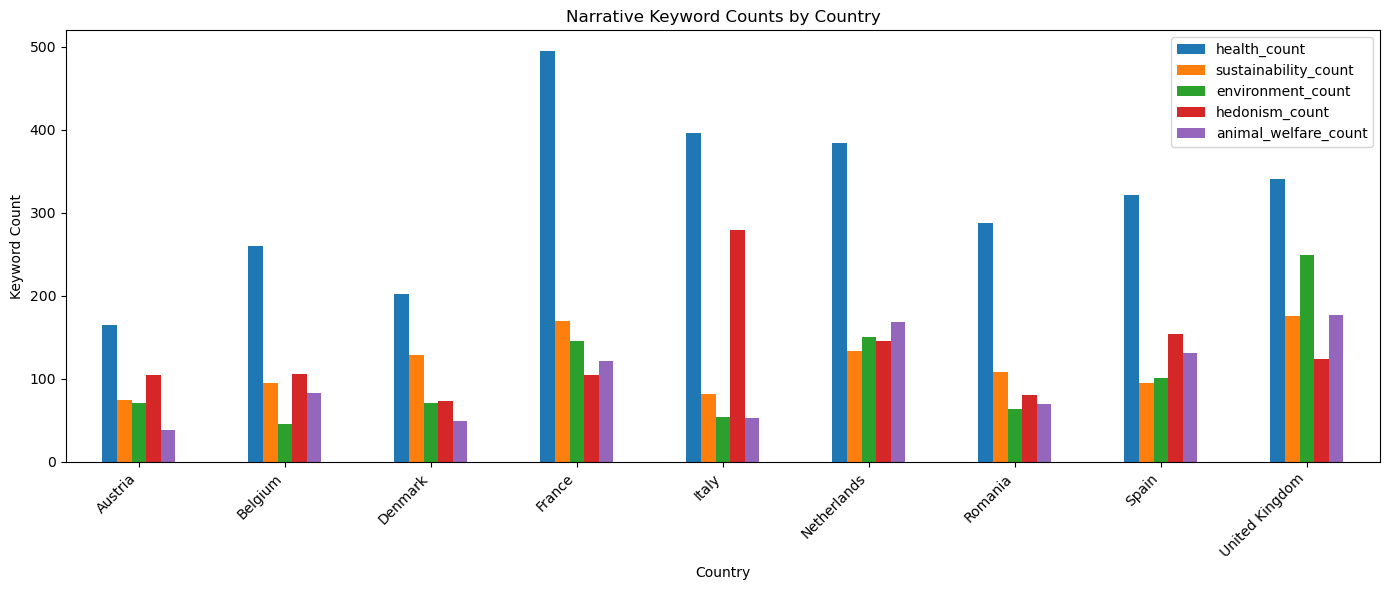

In [149]:

plot_df = country_narrative_summary.set_index("country")[narrative_count_cols]

plot_df.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Narrative Keyword Counts by Country")
plt.xlabel("Country")
plt.ylabel("Keyword Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This figure shows the frequency of different narrative keywords in YouTube videos across countries. Health-related keywords appear most frequently in almost all countries, suggesting that health is the dominant narrative in plant-based food videos. France, Italy, the Netherlands, Spain, and the United Kingdom show relatively high overall narrative counts. Sustainability and environmental narratives are also visible, especially in the United Kingdom and the Netherlands. Hedonism-related keywords are particularly high in Italy, while animal welfare is more prominent in the Netherlands, Spain, and the United Kingdom. Overall, the results suggest that health is the main narrative, but the emphasis on other narratives varies across countries.

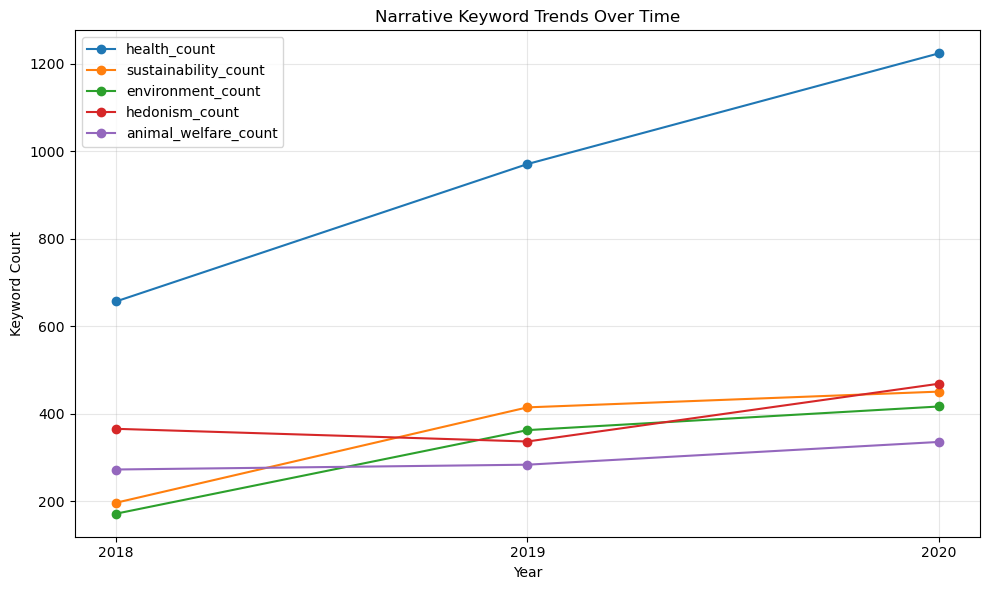

In [150]:
trend_df = country_year_narrative_summary.groupby("Year")[narrative_count_cols].sum()

trend_df.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Narrative Keyword Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Keyword Count")
plt.xticks([2018, 2019, 2020])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This figure shows how narrative keyword counts changed from 2018 to 2020. Health-related keywords increased strongly over time and remained the most dominant narrative in every year. Sustainability and environmental narratives also rose steadily, suggesting growing attention to ecological concerns. Hedonism-related keywords dipped slightly in 2019 but increased again in 2020, while animal welfare showed a more moderate upward trend. Overall, the results indicate that plant-based food narratives became more prominent over time, especially around health, sustainability, and environmental themes.

In [151]:
sales_year_country = df.groupby(['Country', 'Year'])[['Value EUR', 'Volume kg/l']].mean().reset_index()

sales_year_country.head()

,Country,Year,Value EUR,Volume kg/l
0,Austria,2018.0,4.549587e+07,1.390068e+07
1,Austria,2019.0,5.161428e+07,1.598722e+07
2,Austria,2020.0,7.406613e+07,2.179194e+07
3,Belgium,2018.0,8.100980e+07,2.826710e+07
4,Belgium,2019.0,8.338846e+07,2.829695e+07


In [152]:
narrative_path = Path("../data/Raw/youtube_narrative_summary_by_country_year.csv")

narrative_df = pd.read_csv(narrative_path)

narrative_df = narrative_df.rename(columns={
    "country": "Country"
})

narrative_df.head()

,Country,Year,video_count,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned
0,Austria,2018,62,46,29,16,22,6,0.322581,0.129032,0.177419,0.177419,0.048387
1,Austria,2019,93,47,23,11,35,10,0.225806,0.118280,0.075269,0.204301,0.064516
2,Austria,2020,110,72,23,44,48,23,0.209091,0.154545,0.136364,0.227273,0.090909
3,Belgium,2018,75,45,19,5,29,44,0.240000,0.093333,0.053333,0.226667,0.133333
4,Belgium,2019,100,107,34,15,30,16,0.280000,0.140000,0.050000,0.190000,0.080000


In [153]:
narrative_df["health_per_video"] = narrative_df["health_count"] / narrative_df["video_count"]

narrative_df["sustainability_environment_per_video"] = (
    narrative_df["sustainability_count"] + narrative_df["environment_count"]
) / narrative_df["video_count"]

narrative_df.head()

,Country,Year,video_count,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned,health_per_video,sustainability_environment_per_video
0,Austria,2018,62,46,29,16,22,6,0.322581,0.129032,0.177419,0.177419,0.048387,0.741935,0.725806
1,Austria,2019,93,47,23,11,35,10,0.225806,0.118280,0.075269,0.204301,0.064516,0.505376,0.365591
2,Austria,2020,110,72,23,44,48,23,0.209091,0.154545,0.136364,0.227273,0.090909,0.654545,0.609091
3,Belgium,2018,75,45,19,5,29,44,0.240000,0.093333,0.053333,0.226667,0.133333,0.600000,0.320000
4,Belgium,2019,100,107,34,15,30,16,0.280000,0.140000,0.050000,0.190000,0.080000,1.070000,0.490000


In [154]:
merged_df = pd.merge(
    sales_year_country,
    narrative_df,
    on=["Country", "Year"],
    how="inner"
)

print(merged_df.shape)
display(merged_df.head())

(27, 17)


,Country,Year,Value EUR,Volume kg/l,video_count,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned,health_per_video,sustainability_environment_per_video
0,Austria,2018.0,4.549587e+07,1.390068e+07,62,46,29,16,22,6,0.322581,0.129032,0.177419,0.177419,0.048387,0.741935,0.725806
1,Austria,2019.0,5.161428e+07,1.598722e+07,93,47,23,11,35,10,0.225806,0.118280,0.075269,0.204301,0.064516,0.505376,0.365591
2,Austria,2020.0,7.406613e+07,2.179194e+07,110,72,23,44,48,23,0.209091,0.154545,0.136364,0.227273,0.090909,0.654545,0.609091
3,Belgium,2018.0,8.100980e+07,2.826710e+07,75,45,19,5,29,44,0.240000,0.093333,0.053333,0.226667,0.133333,0.600000,0.320000
4,Belgium,2019.0,8.338846e+07,2.829695e+07,100,107,34,15,30,16,0.280000,0.140000,0.050000,0.190000,0.080000,1.070000,0.490000


In [155]:
corr1_df = merged_df[["health_per_video", "Value EUR"]].dropna()

X = sm.add_constant(corr1_df["health_per_video"])
y = corr1_df["Value EUR"]

model_health_value = sm.OLS(y, X).fit()

print(model_health_value.summary())

                            OLS Regression Results                            
Dep. Variable:              Value EUR   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     3.584
Date:                Tue, 09 Jun 2026   Prob (F-statistic):             0.0700
Time:                        15:08:05   Log-Likelihood:                -540.50
No. Observations:                  27   AIC:                             1085.
Df Residuals:                      25   BIC:                             1088.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2.503e+07   7.73e+07  

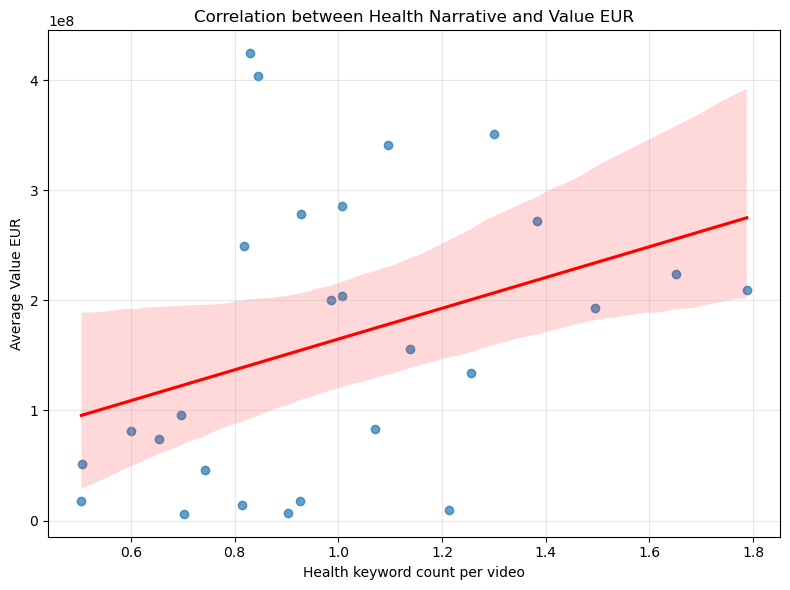

In [156]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=corr1_df,
    x="health_per_video",
    y="Value EUR",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.title("Correlation between Health Narrative and Value EUR")
plt.xlabel("Health keyword count per video")
plt.ylabel("Average Value EUR")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The OLS regression examines whether health-related YouTube narrative intensity is associated with average sales value in EUR. The coefficient for health_per_video is positive, suggesting that country-year observations with more health-related keywords per video tend to have higher average sales value. However, the relationship is not statistically significant, as the p-value is 0.337, which is above the 0.05 threshold. The R-squared value is also low at 0.037, meaning that health narrative intensity explains only about 3.7% of the variation in Value EUR.

The scatter plot shows the same pattern: although the regression line slopes upward, the points are widely dispersed and the confidence interval is broad. Therefore, the result should be interpreted as weak and exploratory. In this dataset, health narratives appear to have a positive but non-significant relationship with sales value.

In [157]:
corr2_df = merged_df[["sustainability_environment_per_video", "Volume kg/l"]].dropna()

X = sm.add_constant(corr2_df["sustainability_environment_per_video"])
y = corr2_df["Volume kg/l"]

model_sustainability_volume = sm.OLS(y, X).fit()

print(model_sustainability_volume.summary())

                            OLS Regression Results                            
Dep. Variable:            Volume kg/l   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.038
Method:                 Least Squares   F-statistic:                   0.04334
Date:                Tue, 09 Jun 2026   Prob (F-statistic):              0.837
Time:                        15:08:05   Log-Likelihood:                -528.64
No. Observations:                  27   AIC:                             1061.
Df Residuals:                      25   BIC:                             1064.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


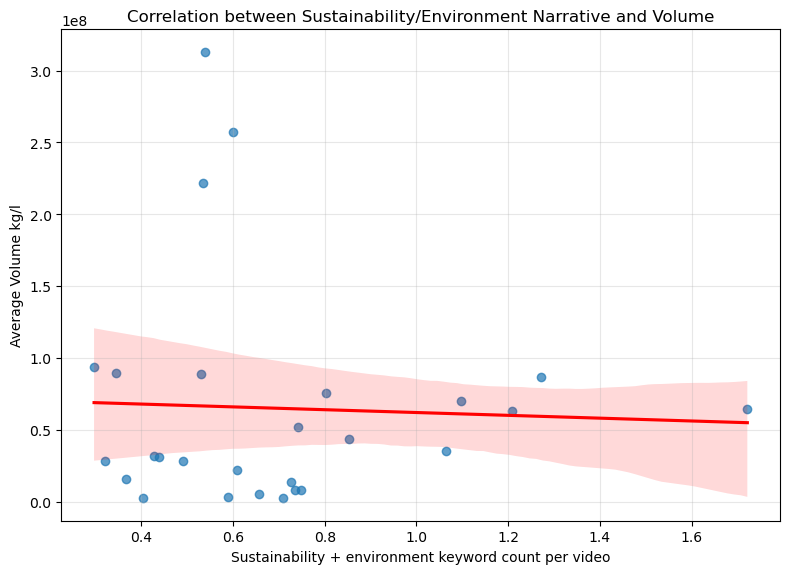

In [158]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=corr2_df,
    x="sustainability_environment_per_video",
    y="Volume kg/l",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.title("Correlation between Sustainability/Environment Narrative and Volume")
plt.xlabel("Sustainability + environment keyword count per video")
plt.ylabel("Average Volume kg/l")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The regression examines whether sustainability and environment narrative intensity is related to average sales volume. The coefficient is negative, suggesting a weak negative relationship between sustainability/environment keywords per video and volume. However, the p-value is 0.565, which is above 0.05, so this relationship is not statistically significant.

The R-squared value is only 0.013, meaning that this narrative variable explains very little variation in sales volume. Overall, the result suggests that sustainability and environmental narratives are not strongly associated with sales volume in this dataset.

In [159]:
sales_year_country = df.groupby(['Country', 'Year'])[['Value EUR', 'Volume kg/l']].mean().reset_index()

narrative_path = "../data/Raw/youtube_narrative_summary_by_country_year.csv"
narrative_df = pd.read_csv(narrative_path)

narrative_df = narrative_df.rename(columns={"country": "Country"})

merged_df = pd.merge(
    sales_year_country,
    narrative_df,
    on=["Country", "Year"],
    how="inner"
)

In [160]:
narrative_cols = [
    "health_count",
    "sustainability_count",
    "environment_count",
    "hedonism_count",
    "animal_welfare_count"
]

for col in narrative_cols:
    merged_df[col.replace("_count", "_per_video")] = (
        merged_df[col] / merged_df["video_count"]
    )

merged_df["total_narrative_per_video"] = (
    merged_df["health_per_video"] +
    merged_df["sustainability_per_video"] +
    merged_df["environment_per_video"] +
    merged_df["hedonism_per_video"] +
    merged_df["animal_welfare_per_video"]
)

In [161]:
corr_vars = [
    "Value EUR",
    "Volume kg/l",
    "video_count",
    "health_per_video",
    "sustainability_per_video",
    "environment_per_video",
    "hedonism_per_video",
    "animal_welfare_per_video",
    "total_narrative_per_video"
]

corr_matrix = merged_df[corr_vars].corr()

corr_matrix

,Value EUR,Volume kg/l,video_count,health_per_video,sustainability_per_video,environment_per_video,hedonism_per_video,animal_welfare_per_video,total_narrative_per_video
Value EUR,1.000000,0.867339,0.352793,0.354081,-0.050418,0.324783,0.364969,0.319397,0.468207
Volume kg/l,0.867339,1.000000,0.201643,0.124415,-0.191411,0.076174,0.183395,0.199782,0.157481
video_count,0.352793,0.201643,1.000000,0.097581,0.099199,0.129828,-0.048564,-0.101884,0.062395
health_per_video,0.354081,0.124415,0.097581,1.000000,0.292380,0.351102,0.169593,0.269130,0.787970
sustainability_per_video,-0.050418,-0.191411,0.099199,0.292380,1.000000,0.599596,-0.518843,0.146036,0.444495
environment_per_video,0.324783,0.076174,0.129828,0.351102,0.599596,1.000000,-0.165830,0.531233,0.732967
hedonism_per_video,0.364969,0.183395,-0.048564,0.169593,-0.518843,-0.165830,1.000000,0.152991,0.258203
animal_welfare_per_video,0.319397,0.199782,-0.101884,0.269130,0.146036,0.531233,0.152991,1.000000,0.689648
total_narrative_per_video,0.468207,0.157481,0.062395,0.787970,0.444495,0.732967,0.258203,0.689648,1.000000


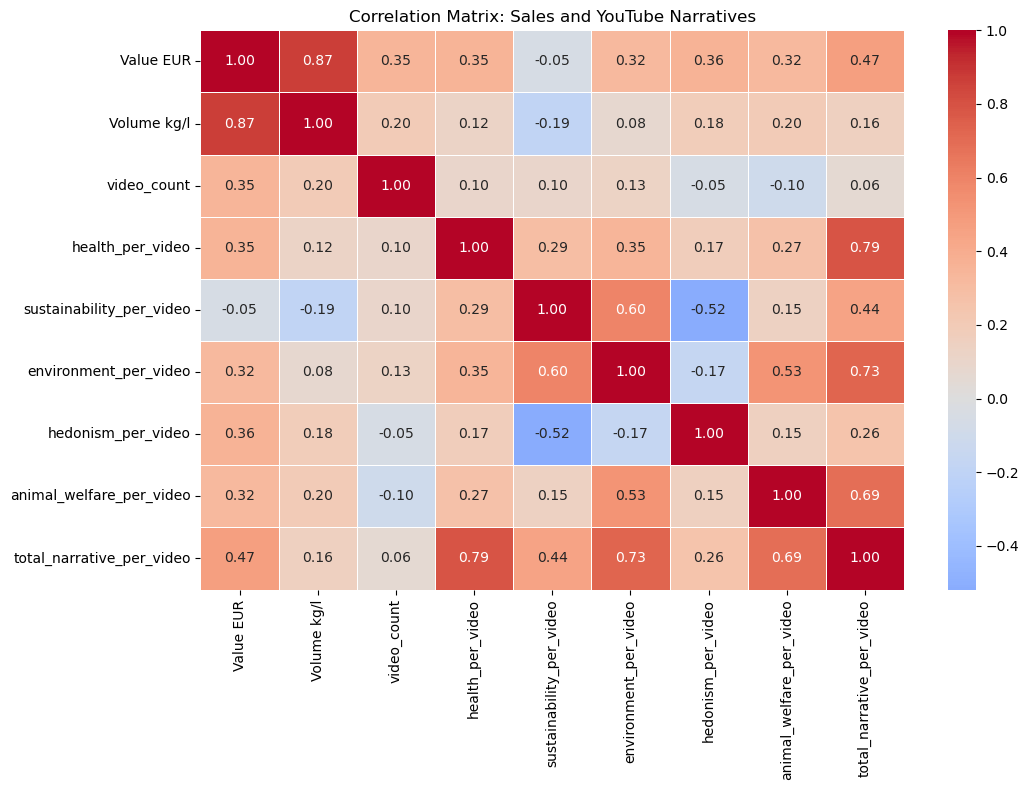

In [162]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix: Sales and YouTube Narratives")
plt.tight_layout()
plt.show()

This correlation matrix shows the relationships between sales indicators and YouTube narrative variables. The strongest relationship is between Value EUR and Volume kg/l with a correlation of 0.94, indicating that higher sales volume is strongly associated with higher market value. In contrast, the correlations between sales variables and narrative variables are generally weak. For example, Value EUR has only weak positive correlations with video_count, health_per_video, hedonism_per_video, and total_narrative_per_video.

The matrix also shows that some narrative categories are strongly related to each other. For example, health_per_video is highly correlated with total_narrative_per_video, and environment_per_video is also strongly related to total narrative intensity. Overall, the results suggest that sales value and volume are closely connected, while YouTube narratives have weaker and more exploratory associations with sales performance.

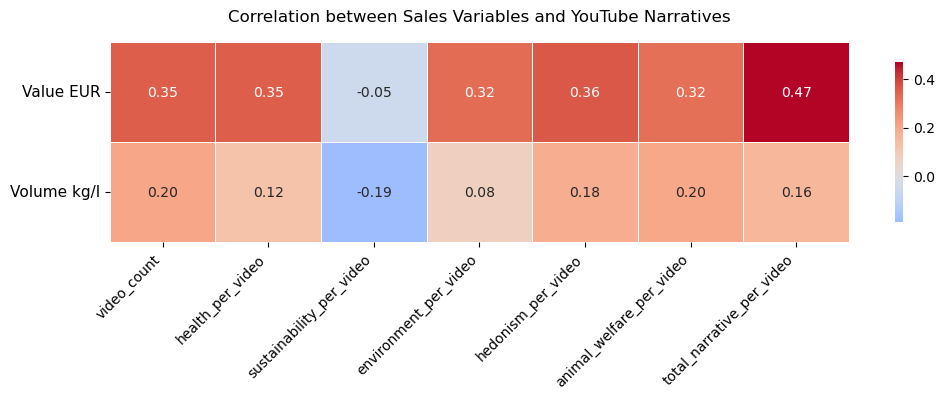

In [163]:
sales_vars = ["Value EUR", "Volume kg/l"]

narrative_vars = [
    "video_count",
    "health_per_video",
    "sustainability_per_video",
    "environment_per_video",
    "hedonism_per_video",
    "animal_welfare_per_video",
    "total_narrative_per_video"
]

sales_narrative_corr = merged_df[sales_vars + narrative_vars].corr().loc[
    sales_vars,
    narrative_vars
]

plt.figure(figsize=(12, 4))

ax = sns.heatmap(
    sales_narrative_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation between Sales Variables and YouTube Narratives", pad=15)

# Make y-axis labels readable
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=11
)

# Make x-axis labels readable
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=10
)

# Add more margin on the left and bottom
plt.subplots_adjust(left=0.18, bottom=0.35, right=0.95, top=0.85)

plt.show()

This heatmap shows that the correlations between sales variables and YouTube narratives are generally weak. Value EUR has the strongest positive correlation with video_count at 0.34, suggesting that higher YouTube attention is somewhat associated with higher sales value. Hedonism, animal welfare, and total narrative intensity also show weak positive correlations with Value EUR. In contrast, sustainability has a weak negative correlation with both Value EUR and Volume kg/l. Overall, YouTube narratives show only limited correlation with sales performance.

In [164]:
corr_long = sales_narrative_corr.stack().reset_index()
corr_long.columns = ["sales_variable", "narrative_variable", "correlation"]

corr_long["abs_correlation"] = corr_long["correlation"].abs()

top_corr = corr_long.sort_values(
    "abs_correlation",
    ascending=False
).head(2)

top_corr


,sales_variable,narrative_variable,correlation,abs_correlation
6,Value EUR,total_narrative_per_video,0.468207,0.468207
4,Value EUR,hedonism_per_video,0.364969,0.364969


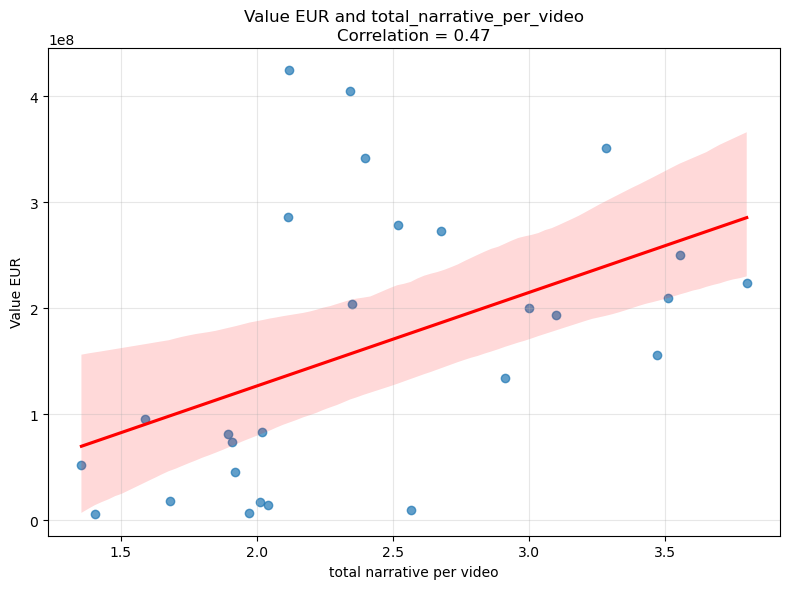

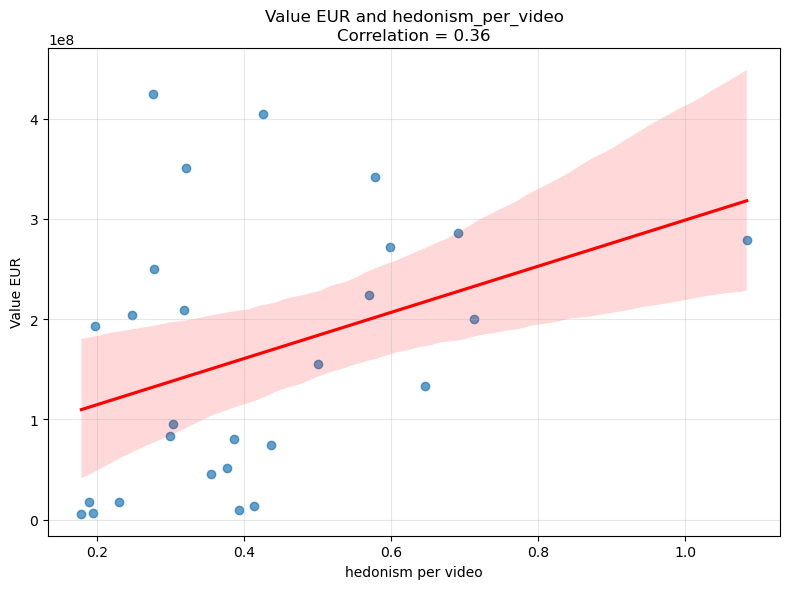

In [165]:
for _, row in top_corr.iterrows():
    sales_var = row["sales_variable"]
    narrative_var = row["narrative_variable"]
    corr_value = row["correlation"]

    plt.figure(figsize=(8, 6))

    sns.regplot(
        data=merged_df,
        x=narrative_var,
        y=sales_var,
        scatter_kws={"alpha": 0.7},
        line_kws={"color": "red"}
    )

    plt.title(
        f"{sales_var} and {narrative_var}\nCorrelation = {corr_value:.2f}"
    )
    plt.xlabel(narrative_var.replace("_", " "))
    plt.ylabel(sales_var)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

These two scatter plots show weak positive relationships between YouTube activity/narratives and sales value. The first plot shows that video_count has a modest positive correlation with Value EUR (r = 0.34), suggesting that country-year groups with more YouTube videos tend to have higher sales value. The second plot shows a weaker positive correlation between hedonism_per_video and Value EUR (r = 0.25), indicating that taste or enjoyment-related narratives may be slightly associated with higher sales value. However, both relationships are relatively weak, so they should be interpreted as exploratory rather than strong evidence.